# Cross-Model Analysis — Polymarket ML

**DS-GA 1003 | NYU**  
**Team:** Dhairya Dhamani, Hector Thompson Baroni, Sachin Sastri

Unified analysis across all five models trained on Polymarket prediction market data.

| Section | Topic |
|---|---|
| 0 | Setup & Data Loading |
| 1 | Overall Performance Summary (RQ1) |
| 2 | Trends Data Impact (RQ2) |
| 3 | Lifecycle Stage Analysis (RQ3) |
| 4 | Market-Level Analysis |
| 5 | Category-Level Analysis |
| 6 | Calibration Analysis |
| 7 | Error Analysis |
| 8 | Why Some Models Outperform Others |

**SVM note:** SVM was trained on a subsampled dataset (fixed lifecycle percentiles: 20/30/40/50/60/70/80%), yielding 29,219 rows vs 288,490 for the other models. Direct comparison of absolute AUC values is not fair — SVM results are shown separately where relevant.

## Section 0 — Setup & Data Loading

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss,
    average_precision_score, roc_curve, precision_recall_curve,
)
from sklearn.calibration import calibration_curve

ROOT = Path('../')
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

# ── Paths ──────────────────────────────────────────────────────────────
DATA_CLEAN     = ROOT / 'data/polymarket_ml_dataset_clean.parquet'
DATA_TRENDS    = ROOT / 'data/polymarket_ml_dataset_with_trends_clean.parquet'

PRED_LR        = ROOT / 'models/logistic_regression/predictions/predictions.csv'
PRED_GB        = ROOT / 'models/gradient_boosting/predictions/predictions.csv'
PRED_RF        = ROOT / 'models/random_forest/predictions/test_predictions.csv'
PRED_RF_TR     = ROOT / 'models/random_forest_trends/predictions/trends_test_predictions.csv'
PRED_SVM       = ROOT / 'models/svm/predictions/predictions_no_trends_shared.csv'
PRED_SVM_TR    = ROOT / 'models/svm/predictions/predictions_with_trends.csv'

COLORS = {
    'Market Baseline': '#78909C',
    'LR':              '#E91E63',
    'LR+Trends':       '#F48FB1',
    'GB':              '#FF9800',
    'GB+Trends':       '#FFCC80',
    'RF':              '#2196F3',
    'RF+Trends':       '#4CAF50',
    'SVM':             '#9C27B0',
    'SVM+Trends':      '#CE93D8',
    'Ensemble':        '#FF5722',
}

# ── Helper functions ────────────────────────────────────────────────────
def metrics(y_true, y_proba, brier_baseline=None):
    p = np.clip(y_proba, 1e-7, 1 - 1e-7)
    b = brier_score_loss(y_true, p)
    bss = (brier_baseline - b) / brier_baseline if brier_baseline else np.nan
    return {
        'AUC-ROC':  round(roc_auc_score(y_true, p), 4),
        'PR-AUC':   round(average_precision_score(y_true, p), 4),
        'Log-loss': round(log_loss(y_true, p), 4),
        'Brier':    round(b, 4),
        'BSS':      round(bss, 4),
    }

def ece(y_true, y_proba, n_bins=10):
    frac, mean_pred = calibration_curve(y_true, y_proba, n_bins=n_bins)
    edges = np.linspace(0, 1, n_bins + 1)
    bin_weights = np.array([
        ((y_proba >= edges[i]) & (y_proba < edges[i+1])).mean()
        for i in range(n_bins)
    ])[:len(frac)]
    return round(float(np.sum(np.abs(frac - mean_pred) * bin_weights)), 4)

print('Setup complete.')

Setup complete.


In [3]:
# ── Load parquet test set ───────────────────────────────────────────────
print('Loading parquet...')
pq_full = pd.read_parquet(DATA_CLEAN)
test_pq = pq_full[pq_full['split'] == 'test'].copy()
test_pq['snapshot_timestamp'] = pd.to_datetime(test_pq['snapshot_timestamp'], utc=True)
test_pq = test_pq.sort_values(['market_id', 'snapshot_timestamp']).reset_index(drop=True)
test_pq['snap_idx'] = test_pq.groupby('market_id').cumcount()  # 0-based within-market index

print(f'Test parquet: {len(test_pq):,} rows | {test_pq["market_id"].nunique():,} markets')
print(f'YES rate: {test_pq["outcome"].mean():.3f} | Categories: {sorted(test_pq["category"].unique())}')

# Market-level metadata (one row per market)
market_meta = (
    test_pq.sort_values(['market_id', 'snapshot_timestamp'])
    .groupby('market_id')
    .agg(
        outcome=('outcome', 'first'),
        category=('category', 'first'),
        log_volume=('log_volume', 'first'),
        total_volume=('total_volume', 'first'),
        duration_days=('duration_days', 'first'),
        n_snapshots=('snapshot_timestamp', 'count'),
    )
    .reset_index()
)
print(f'Market meta: {len(market_meta):,} markets')

Loading parquet...
Test parquet: 288,490 rows | 4,174 markets
YES rate: 0.210 | Categories: ['crypto', 'entertainment', 'finance', 'geopolitics', 'other', 'politics_global', 'politics_us', 'science_tech', 'sports']
Market meta: 4,174 markets


In [4]:
# ── Load prediction CSVs ────────────────────────────────────────────────
print('Loading prediction CSVs...')
lr    = pd.read_csv(PRED_LR)
gb    = pd.read_csv(PRED_GB)
rf    = pd.read_csv(PRED_RF)
rf_tr = pd.read_csv(PRED_RF_TR)
svm   = pd.read_csv(PRED_SVM)
svm_tr= pd.read_csv(PRED_SVM_TR)

# Add within-market snap index (same sort used for parquet → aligns rows)
for df in [lr, gb]:
    df.sort_values('market_id', inplace=True)
    df['snap_idx'] = df.groupby('market_id').cumcount()
    df.reset_index(drop=True, inplace=True)

# Join LR/GB with parquet meta via (market_id, snap_idx)
pq_key = test_pq[['market_id', 'snap_idx', 'snapshot_timestamp',
                   'pct_lifetime_elapsed', 'price_at_snapshot',
                   'category', 'days_before_close', 'outcome']]

lr_j = lr.merge(pq_key, on=['market_id', 'snap_idx'], how='inner', suffixes=('_lr',''))
gb_j = gb.merge(pq_key, on=['market_id', 'snap_idx'], how='inner', suffixes=('_gb',''))

# RF/RF-Trends: join on market_id + snapshot_timestamp
rf['snapshot_timestamp']    = pd.to_datetime(rf['snapshot_timestamp'], utc=True)
rf_tr['snapshot_timestamp'] = pd.to_datetime(rf_tr['snapshot_timestamp'], utc=True)

rf_j    = rf.merge(pq_key, on=['market_id', 'snapshot_timestamp'], how='inner', suffixes=('','_pq'))
rf_tr_j = rf_tr.merge(pq_key, on=['market_id', 'snapshot_timestamp'], how='inner', suffixes=('','_pq'))

# Canonical proba columns
lr_j['proba']    = lr_j['pred_prob_base']
gb_j['proba']    = gb_j['pred_prob_base']
rf_j['proba']    = rf_j['proba_full_calibrated']
rf_tr_j['proba'] = rf_tr_j['proba_trends_calibrated']
svm['proba']     = svm['pred_proba_nt']
svm_tr['proba']  = svm_tr['pred_proba_wt']

# Market baseline (price_at_snapshot)
BASELINE = np.clip(test_pq['price_at_snapshot'].values, 1e-6, 1-1e-6)
Y_TEST   = test_pq['outcome'].values
baseline_brier = brier_score_loss(Y_TEST, BASELINE)

print(f'LR joined:        {len(lr_j):,} rows')
print(f'GB joined:        {len(gb_j):,} rows')
print(f'RF joined:        {len(rf_j):,} rows')
print(f'RF+Trends joined: {len(rf_tr_j):,} rows')
print(f'SVM:              {len(svm):,} rows | {svm["market_id"].nunique():,} markets')
print(f'Market baseline Brier: {baseline_brier:.4f}')

Loading prediction CSVs...
LR joined:        288,490 rows
GB joined:        288,490 rows
RF joined:        288,490 rows
RF+Trends joined: 288,490 rows
SVM:              29,064 rows | 4,152 markets
Market baseline Brier: 0.1004


---
## Section 1 — Overall Performance Summary (RQ1)

**RQ1:** Can ML models outperform prediction market probabilities in forecasting outcomes?

Metrics:
- **AUC-ROC** — discrimination ability (threshold-free)
- **PR-AUC** — precision-recall; more informative than AUC-ROC under class imbalance (77.6% NO)
- **Log-loss** — probabilistic accuracy; penalises confident wrong predictions
- **Brier Score** — mean squared probability error (lower = better)
- **Brier Skill Score (BSS)** = `(Brier_baseline − Brier_model) / Brier_baseline` — % improvement over market baseline; normalises for task difficulty

In [5]:
# ── Snapshot-level metrics — all base + trends variants ─────────────────
snap_results = {}
snap_results['Market Baseline'] = metrics(Y_TEST, BASELINE)
snap_results['Market Baseline']['BSS'] = 0.0

for name, df, col in [
    ('LR',         lr_j,    'pred_prob_base'),
    ('LR+Trends',  lr_j,    'pred_prob_trends'),
    ('GB',         gb_j,    'pred_prob_base'),
    ('GB+Trends',  gb_j,    'pred_prob_trends'),
    ('RF',         rf_j,    'proba_full_calibrated'),
    ('RF+Trends',  rf_tr_j, 'proba_trends_calibrated'),
]:
    snap_results[name] = metrics(df['outcome'].values, df[col].values, baseline_brier)

# Also update canonical proba columns for downstream use
lr_j['proba']       = lr_j['pred_prob_base']
lr_j['proba_tr']    = lr_j['pred_prob_trends']
gb_j['proba']       = gb_j['pred_prob_base']
gb_j['proba_tr']    = gb_j['pred_prob_trends']
rf_j['proba']       = rf_j['proba_full_calibrated']
rf_tr_j['proba']    = rf_tr_j['proba_trends_calibrated']

# SVM: separate subset (29K rows, fixed percentile snapshots — not directly comparable)
svm_baseline   = np.clip(svm['baseline'].values, 1e-6, 1-1e-6)
svm_brier_base = brier_score_loss(svm['outcome'].values, svm_baseline)
svm_results = {
    'SVM Baseline': metrics(svm['outcome'].values,    svm_baseline),
    'SVM':          metrics(svm['outcome'].values,    svm['pred_proba_nt'].values, svm_brier_base),
    'SVM+Trends':   metrics(svm_tr['outcome'].values, svm_tr['pred_proba_wt'].values, svm_brier_base),
}
svm_results['SVM Baseline']['BSS'] = 0.0

results_df = pd.DataFrame(snap_results).T
svm_df     = pd.DataFrame(svm_results).T

print('=== Snapshot-level models (288,490 test snapshots) ===')
print(results_df[['AUC-ROC','PR-AUC','Log-loss','Brier','BSS']].to_string())
print()
print('=== SVM (29,219 subsampled snapshots — not directly comparable) ===')
print(svm_df[['AUC-ROC','PR-AUC','Log-loss','Brier','BSS']].to_string())

=== Snapshot-level models (288,490 test snapshots) ===
                 AUC-ROC  PR-AUC  Log-loss   Brier     BSS
Market Baseline   0.8890  0.7440    0.3278  0.1004  0.0000
LR                0.8881  0.7231    0.4105  0.1255 -0.2499
LR+Trends         0.8882  0.7227    0.4101  0.1254 -0.2482
GB                0.9049  0.7667    0.3475  0.1080 -0.0753
GB+Trends         0.9047  0.7681    0.3454  0.1079 -0.0738
RF                0.9018  0.7527    0.3027  0.0922  0.0820
RF+Trends         0.9034  0.7598    0.3011  0.0914  0.0902

=== SVM (29,219 subsampled snapshots — not directly comparable) ===
              AUC-ROC  PR-AUC  Log-loss   Brier     BSS
SVM Baseline   0.9402  0.8229    0.2196  0.0655  0.0000
SVM            0.9398  0.8126    0.2226  0.0651  0.0059
SVM+Trends     0.9405  0.8138    0.2217  0.0649  0.0092


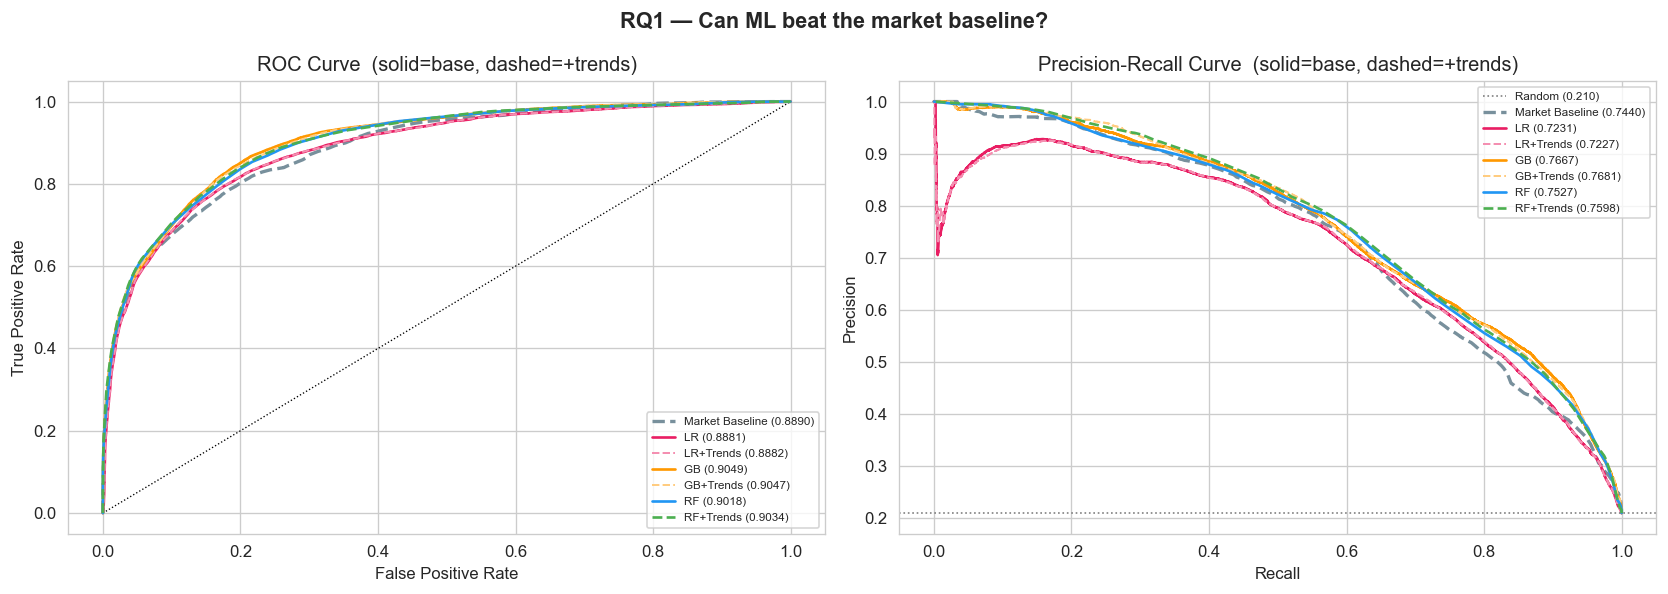

In [6]:
# ── ROC + PR curves — all variants ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Base models: solid lines | Trends variants: dashed lines
plot_items = [
    ('Market Baseline', Y_TEST,             BASELINE,                     '--', 2.0),
    ('LR',              lr_j['outcome'],    lr_j['pred_prob_base'],       '-',  1.6),
    ('LR+Trends',       lr_j['outcome'],    lr_j['pred_prob_trends'],     '--', 1.2),
    ('GB',              gb_j['outcome'],    gb_j['pred_prob_base'],       '-',  1.6),
    ('GB+Trends',       gb_j['outcome'],    gb_j['pred_prob_trends'],     '--', 1.2),
    ('RF',              rf_j['outcome'],    rf_j['proba_full_calibrated'],'-',  1.6),
    ('RF+Trends',       rf_tr_j['outcome'], rf_tr_j['proba_trends_calibrated'], '--', 1.6),
]

# ROC
ax = axes[0]
ax.plot([0,1],[0,1],'k:',lw=0.8)
for name, y, p, ls, lw in plot_items:
    fpr, tpr, _ = roc_curve(y, p)
    auc = roc_auc_score(y, p)
    ax.plot(fpr, tpr, color=COLORS[name], ls=ls, lw=lw, label=f'{name} ({auc:.4f})')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve  (solid=base, dashed=+trends)')
ax.legend(fontsize=7)

# PR
ax = axes[1]
yes_rate = Y_TEST.mean()
ax.axhline(yes_rate, color='gray', ls=':', lw=1, label=f'Random ({yes_rate:.3f})')
for name, y, p, ls, lw in plot_items:
    prec, rec, _ = precision_recall_curve(y, p)
    pr_auc = average_precision_score(y, p)
    ax.plot(rec, prec, color=COLORS[name], ls=ls, lw=lw, label=f'{name} ({pr_auc:.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve  (solid=base, dashed=+trends)')
ax.legend(fontsize=7)

plt.suptitle('RQ1 — Can ML beat the market baseline?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 2 — Trends Data Impact (RQ2)

**RQ2:** Do Google Trends features add predictive value?

Three models have base + trends variants: LR, GB, RF. We compare them directly and ask:
- How much does each metric change when trends are added?
- Does the gain depend on whether trends data was actually available for that snapshot?
- Which market categories benefit most from trends features?

In [10]:
# ── Trends delta table ──────────────────────────────────────────────────
trend_pairs = [
    ('LR',  lr_j['outcome'].values,    lr_j['pred_prob_base'].values,    lr_j['pred_prob_trends'].values),
    ('GB',  gb_j['outcome'].values,    gb_j['pred_prob_base'].values,    gb_j['pred_prob_trends'].values),
    ('RF',  rf_tr_j['outcome'].values, rf_tr_j['proba_full'].values,     rf_tr_j['proba_trends_calibrated'].values),
]

delta_rows = []
for model, y, p_base, p_trends in trend_pairs:
    m_base   = metrics(y, p_base,   baseline_brier)
    m_trends = metrics(y, p_trends, baseline_brier)
    delta_rows.append({
        'Model':       model,
        'AUC (base)':  m_base['AUC-ROC'],
        'AUC (trends)':m_trends['AUC-ROC'],
        'ΔAUC':        round(m_trends['AUC-ROC']  - m_base['AUC-ROC'],  4),
        'ΔLog-loss':   round(m_trends['Log-loss'] - m_base['Log-loss'], 4),
        'ΔBrier':      round(m_trends['Brier']    - m_base['Brier'],    4),
        'ΔBSS':        round(m_trends['BSS']      - m_base['BSS'],      4),
    })

delta_df = pd.DataFrame(delta_rows)
print('Trends delta (negative ΔLog-loss / ΔBrier = improvement):')
print(delta_df.to_string(index=False))

Trends delta (negative ΔLog-loss / ΔBrier = improvement):
Model  AUC (base)  AUC (trends)    ΔAUC  ΔLog-loss  ΔBrier   ΔBSS
   LR      0.8881        0.8882  0.0001    -0.0004 -0.0001 0.0017
   GB      0.9049        0.9047 -0.0002    -0.0021 -0.0001 0.0015
   RF      0.9023        0.9034  0.0011    -0.0470 -0.0174 0.1736


In [11]:
# ── Trends data coverage and conditional AUC ─────────────────────────────
# Load trends parquet just to get has_trend_data column
print('Loading trends parquet for coverage check...')
pq_trends = pd.read_parquet(DATA_TRENDS, columns=['market_id','snapshot_timestamp','has_trend_data','split'])
pq_trends = pq_trends[pq_trends['split'] == 'test']
pq_trends['snapshot_timestamp'] = pd.to_datetime(pq_trends['snapshot_timestamp'], utc=True)

# Join RF+Trends predictions with has_trend_data
rf_tr_cov = rf_tr_j.merge(
    pq_trends[['market_id','snapshot_timestamp','has_trend_data']],
    on=['market_id','snapshot_timestamp'], how='left'
)

coverage = rf_tr_cov['has_trend_data'].mean()
print(f'Trends data coverage: {coverage:.1%} of test snapshots have trend data')

y       = rf_tr_cov['outcome'].values
p_full  = rf_tr_cov['proba_full'].values
p_trend = rf_tr_cov['proba_trends_calibrated'].values
has_td  = rf_tr_cov['has_trend_data'].fillna(False).astype(bool).values

print('\nConditional AUC — RF Full vs RF+Trends, split by trends data availability:')
print(f'  Rows WITH trends data ({has_td.sum():,}):')
if has_td.sum() > 100 and y[has_td].mean() > 0:
    print(f'    RF Full:    {roc_auc_score(y[has_td], p_full[has_td]):.4f}')
    print(f'    RF+Trends:  {roc_auc_score(y[has_td], p_trend[has_td]):.4f}')
print(f'  Rows WITHOUT trends data ({(~has_td).sum():,}):')
if (~has_td).sum() > 100 and y[~has_td].mean() > 0:
    print(f'    RF Full:    {roc_auc_score(y[~has_td], p_full[~has_td]):.4f}')
    print(f'    RF+Trends:  {roc_auc_score(y[~has_td], p_trend[~has_td]):.4f}')

Loading trends parquet for coverage check...
Trends data coverage: 99.5% of test snapshots have trend data

Conditional AUC — RF Full vs RF+Trends, split by trends data availability:
  Rows WITH trends data (287,126):
    RF Full:    0.9023
    RF+Trends:  0.9035
  Rows WITHOUT trends data (1,364):
    RF Full:    0.8915
    RF+Trends:  0.7392


Trends lift per category (RF Full → RF+Trends):
("other" excluded — no Trends data collected for those 132 markets)
       Category  Snapshots  AUC (Full)  AUC (Trends)    ΔAUC
   science_tech      15530      0.8881        0.8918  0.0037
         crypto      24586      0.9189        0.9223  0.0034
        finance      25093      0.9142        0.9169  0.0027
    politics_us      52699      0.9208        0.9223  0.0015
    geopolitics      16578      0.9385        0.9382 -0.0003
  entertainment      37027      0.9282        0.9278 -0.0004
         sports      93022      0.8752        0.8746 -0.0006
politics_global      22591      0.9140        0.9112 -0.0028


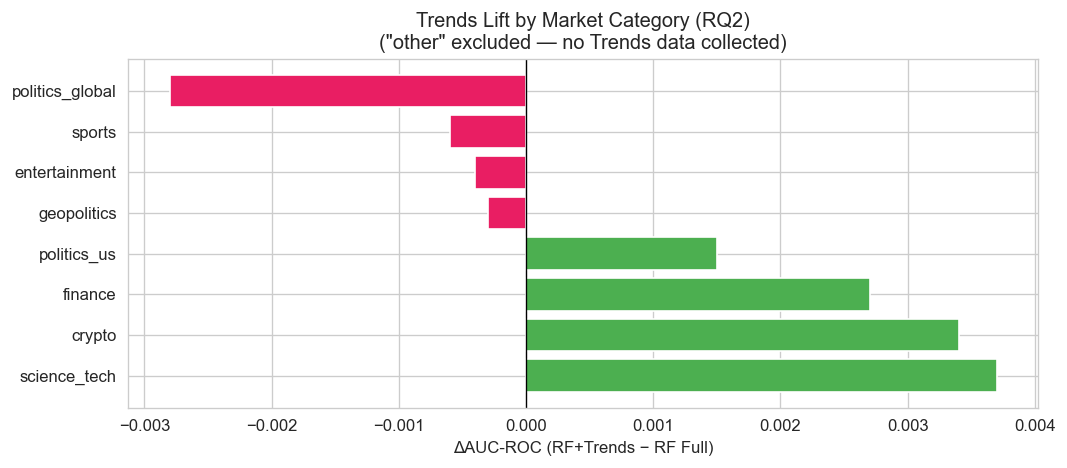

In [12]:
# ── Trends lift by category (RF Full vs RF+Trends) ──────────────────────
# "other" is excluded: Google Trends data was never collected for those 132 markets.
# Every row in "other" has trend_value=0 and has_trend_data=False, so any ΔAUC
# computed there reflects calibration noise, not real trend signal.

cat_trend_rows = []
for cat, grp in rf_tr_j.groupby('category'):
    if cat == 'other':
        continue  # no Trends data collected — comparison is meaningless
    if grp['outcome'].nunique() < 2 or len(grp) < 50:
        continue
    auc_full  = roc_auc_score(grp['outcome'], grp['proba_full'])
    auc_trend = roc_auc_score(grp['outcome'], grp['proba_trends_calibrated'])
    cat_trend_rows.append({
        'Category':    cat,
        'Snapshots':   len(grp),
        'AUC (Full)':  round(auc_full, 4),
        'AUC (Trends)':round(auc_trend, 4),
        'ΔAUC':        round(auc_trend - auc_full, 4),
    })

cat_trend_df = pd.DataFrame(cat_trend_rows).sort_values('ΔAUC', ascending=False)
print('Trends lift per category (RF Full → RF+Trends):')
print('("other" excluded — no Trends data collected for those 132 markets)')
print(cat_trend_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
colors  = ['#4CAF50' if d >= 0 else '#E91E63' for d in cat_trend_df['ΔAUC']]
ax.barh(cat_trend_df['Category'], cat_trend_df['ΔAUC'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('ΔAUC-ROC (RF+Trends − RF Full)')
ax.set_title('Trends Lift by Market Category (RQ2)\n("other" excluded — no Trends data collected)')
plt.tight_layout()
plt.savefig('trends_lift_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3 — Lifecycle Stage Analysis (RQ3)

**RQ3:** At which stage of a market's lifecycle do external signals provide the most value?

Lifecycle buckets based on `pct_lifetime_elapsed`:
- **Early (0–33%):** Market just started. Price is near 0.5, little information. Features and trends should matter most here.
- **Mid (33–67%):** Market in progress. Price has started to move but hasn't converged.
- **Late (67–100%):** Market near resolution. Price has converged strongly toward 0 or 1. Baseline is very strong here.

**Hypothesis:** The gap between model AUC and market baseline should be largest in Early, shrinking toward Late as price becomes the dominant signal.

In [10]:
# ── Lifecycle AUC by stage — all variants ────────────────────────────────
LC_BINS   = [0, 0.33, 0.67, 1.001]
LC_LABELS = ['Early (0-33%)', 'Mid (33-67%)', 'Late (67-100%)']

snap_frame = rf_j[['market_id','snapshot_timestamp','outcome','pct_lifetime_elapsed',
                    'price_at_snapshot','category']].copy()
snap_frame = snap_frame.merge(
    rf_j[['market_id','snapshot_timestamp','proba']].rename(columns={'proba':'p_rf'}),
    on=['market_id','snapshot_timestamp']
).merge(
    rf_tr_j[['market_id','snapshot_timestamp','proba']].rename(columns={'proba':'p_rf_tr'}),
    on=['market_id','snapshot_timestamp'], how='left'
).merge(
    lr_j[['market_id','snap_idx','proba','proba_tr']]
    .rename(columns={'proba':'p_lr','proba_tr':'p_lr_tr'})
    .merge(test_pq[['market_id','snapshot_timestamp','snap_idx']], on=['market_id','snap_idx'])
    [['market_id','snapshot_timestamp','p_lr','p_lr_tr']],
    on=['market_id','snapshot_timestamp'], how='left'
).merge(
    gb_j[['market_id','snap_idx','proba','proba_tr']]
    .rename(columns={'proba':'p_gb','proba_tr':'p_gb_tr'})
    .merge(test_pq[['market_id','snapshot_timestamp','snap_idx']], on=['market_id','snap_idx'])
    [['market_id','snapshot_timestamp','p_gb','p_gb_tr']],
    on=['market_id','snapshot_timestamp'], how='left'
)
snap_frame['p_baseline'] = np.clip(snap_frame['price_at_snapshot'], 1e-6, 1-1e-6)
snap_frame['lc_bucket']  = pd.cut(snap_frame['pct_lifetime_elapsed'], bins=LC_BINS, labels=LC_LABELS)

MODEL_COLS = [
    ('p_lr',    'LR'),
    ('p_lr_tr', 'LR+Trends'),
    ('p_gb',    'GB'),
    ('p_gb_tr', 'GB+Trends'),
    ('p_rf',    'RF'),
    ('p_rf_tr', 'RF+Trends'),
]

lc_rows = []
for bucket, grp in snap_frame.groupby('lc_bucket', observed=True):
    if grp['outcome'].nunique() < 2:
        continue
    y = grp['outcome'].values
    row = {'Stage': bucket, 'Snapshots': len(grp),
           'Baseline': round(roc_auc_score(y, grp['p_baseline']), 4)}
    for col, label in MODEL_COLS:
        valid = grp[col].notna()
        if valid.sum() > 100 and y[valid.values].sum() > 0:
            row[label] = round(roc_auc_score(y[valid.values], grp.loc[valid, col]), 4)
        else:
            row[label] = np.nan
    lc_rows.append(row)

lc_df = pd.DataFrame(lc_rows)
print(lc_df.to_string(index=False))

         Stage  Snapshots  Baseline     LR  LR+Trends     GB  GB+Trends     RF  RF+Trends
 Early (0-33%)     135603    0.8912 0.9103     0.9104 0.9230     0.9234 0.9056     0.9066
  Mid (33-67%)     121905    0.8829 0.8800     0.8799 0.8921     0.8912 0.8963     0.8996
Late (67-100%)      30982    0.8981 0.7997     0.8004 0.8077     0.8077 0.9028     0.8991


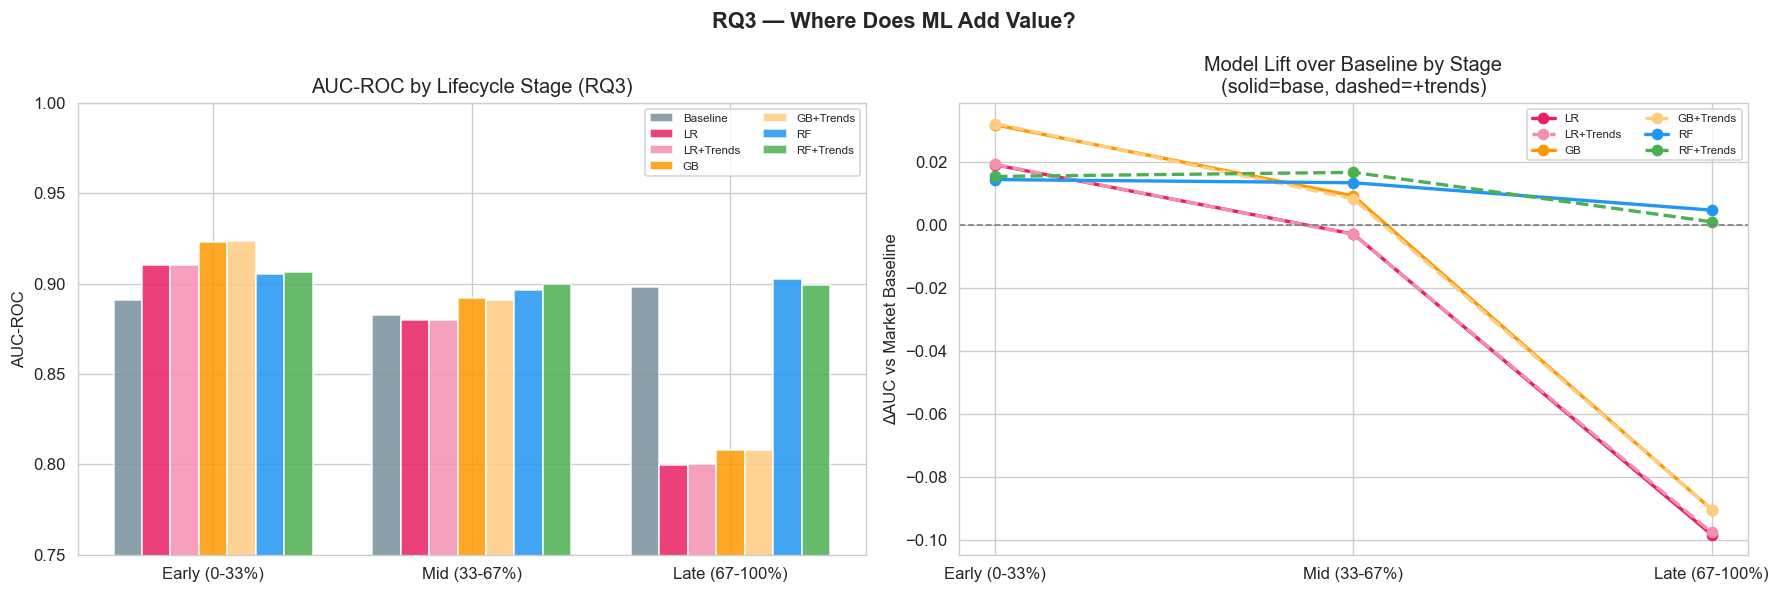

In [11]:
# ── Lifecycle AUC plot — all variants ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

all_model_cols = ['Baseline','LR','LR+Trends','GB','GB+Trends','RF','RF+Trends']
all_colors     = [COLORS['Market Baseline'],COLORS['LR'],COLORS['LR+Trends'],
                  COLORS['GB'],COLORS['GB+Trends'],COLORS['RF'],COLORS['RF+Trends']]

# Left: absolute AUC per stage
ax = axes[0]
x = np.arange(len(lc_df))
w = 0.11
for i, (col, color) in enumerate(zip(all_model_cols, all_colors)):
    if col in lc_df.columns:
        ax.bar(x + (i - 3) * w, lc_df[col], w, label=col, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(lc_df['Stage'])
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC by Lifecycle Stage (RQ3)')
ax.legend(fontsize=7, ncol=2)
min_auc = lc_df[all_model_cols].min().min()
ax.set_ylim(max(0.5, min_auc - 0.05), 1.0)

# Right: delta vs baseline per stage (base=solid, trends=dashed)
ax = axes[1]
for col, color, ls in [
    ('LR',       COLORS['LR'],       '-'),
    ('LR+Trends',COLORS['LR+Trends'],'--'),
    ('GB',       COLORS['GB'],       '-'),
    ('GB+Trends',COLORS['GB+Trends'],'--'),
    ('RF',       COLORS['RF'],       '-'),
    ('RF+Trends',COLORS['RF+Trends'],'--'),
]:
    if col in lc_df.columns:
        delta = lc_df[col] - lc_df['Baseline']
        ax.plot(lc_df['Stage'], delta, 'o'+ls, color=color, lw=2, ms=6, label=col)
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_ylabel('ΔAUC vs Market Baseline')
ax.set_title('Model Lift over Baseline by Stage\n(solid=base, dashed=+trends)')
ax.legend(fontsize=7, ncol=2)

plt.suptitle('RQ3 — Where Does ML Add Value?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lifecycle_auc.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4 — Market-Level Analysis

Snapshots are the unit of prediction, but **markets** are the unit of outcome. Here we aggregate predictions to market level and ask:
- Which markets were predicted well vs poorly across all models?
- Is there a pattern to prediction failures (duration, volume, category)?
- How consistently did each model call the right direction throughout a market's life?
- Which model first detected the correct direction earliest in a market's life?

In [12]:
# ── Build market-level dataframe ─────────────────────────────────────────
def market_agg(df, proba_col, model_name):
    """Aggregate snapshot-level predictions to market level."""
    agg = df.groupby('market_id').agg(
        outcome=(   'outcome',   'first'),
        mean_proba=(proba_col,   'mean'),
        last_proba=(proba_col,   'last'),
        std_proba=( proba_col,   'std'),
    ).reset_index()
    agg['model'] = model_name
    return agg

mkt_lr    = market_agg(lr_j,    'proba', 'LR')
mkt_gb    = market_agg(gb_j,    'proba', 'GB')
mkt_rf    = market_agg(rf_j,    'proba', 'RF')
mkt_rf_tr = market_agg(rf_tr_j, 'proba', 'RF+Trends')

# SVM: already sparse — group by market_id
mkt_svm = svm.groupby('market_id').agg(
    outcome=('outcome','first'),
    mean_proba=('proba','mean'),
    last_proba=('proba','last'),
    std_proba=('proba','std'),
).reset_index()
mkt_svm['model'] = 'SVM'

# Wide table: one row per market, one column per model
wide = market_meta.copy()
for df_mkt, col_name in [(mkt_lr,'p_lr'),(mkt_gb,'p_gb'),(mkt_rf,'p_rf'),(mkt_rf_tr,'p_rf_tr')]:
    wide = wide.merge(df_mkt[['market_id','mean_proba']].rename(columns={'mean_proba':col_name}),
                      on='market_id', how='left')

# Market baseline: last price_at_snapshot for each market
wide = wide.merge(
    test_pq.sort_values(['market_id','snapshot_timestamp'])
    .groupby('market_id')['price_at_snapshot'].last().reset_index()
    .rename(columns={'price_at_snapshot':'p_baseline'}),
    on='market_id', how='left'
)

print(f'Market-level wide table: {len(wide):,} markets × {wide.shape[1]} columns')

Market-level wide table: 4,174 markets × 12 columns


In [13]:
# ── Market-level AUC ─────────────────────────────────────────────────────
mkt_auc_rows = []
y_mkt = wide['outcome'].values
for col, name in [('p_baseline','Market Baseline'),('p_lr','LR'),
                   ('p_gb','GB'),('p_rf','RF'),('p_rf_tr','RF+Trends')]:
    valid = wide[col].notna()
    if valid.sum() < 100:
        continue
    p = np.clip(wide.loc[valid, col].values, 1e-6, 1-1e-6)
    y = y_mkt[valid.values]
    mkt_auc_rows.append({'Model': name, 'Market-level AUC': round(roc_auc_score(y, p), 4),
                         'Market-level PR-AUC': round(average_precision_score(y, p), 4)})

mkt_auc_df = pd.DataFrame(mkt_auc_rows)
print('Market-level AUC (mean probability per market → AUC):')
print('(Compare with snapshot-level AUC in Section 1 — market-level should be higher)')
print(mkt_auc_df.to_string(index=False))

Market-level AUC (mean probability per market → AUC):
(Compare with snapshot-level AUC in Section 1 — market-level should be higher)
          Model  Market-level AUC  Market-level PR-AUC
Market Baseline            0.9622               0.8865
             LR            0.9380               0.8070
             GB            0.9437               0.8312
             RF            0.9463               0.8372
      RF+Trends            0.9464               0.8391


Well-predicted markets (|mean_proba − outcome| < 0.2): 3,283 (78.7%)
Poorly predicted (overconfident wrong): 207 (5.0%)
  Overconfident NO (p_rf<0.35, outcome=YES): 181
  Overconfident YES (p_rf>0.65, outcome=NO):  26

--- Poor predictions by category (RF) ---
category
sports             53
politics_us        38
finance            32
entertainment      27
politics_global    21
crypto             16
science_tech        9
geopolitics         8
other               3


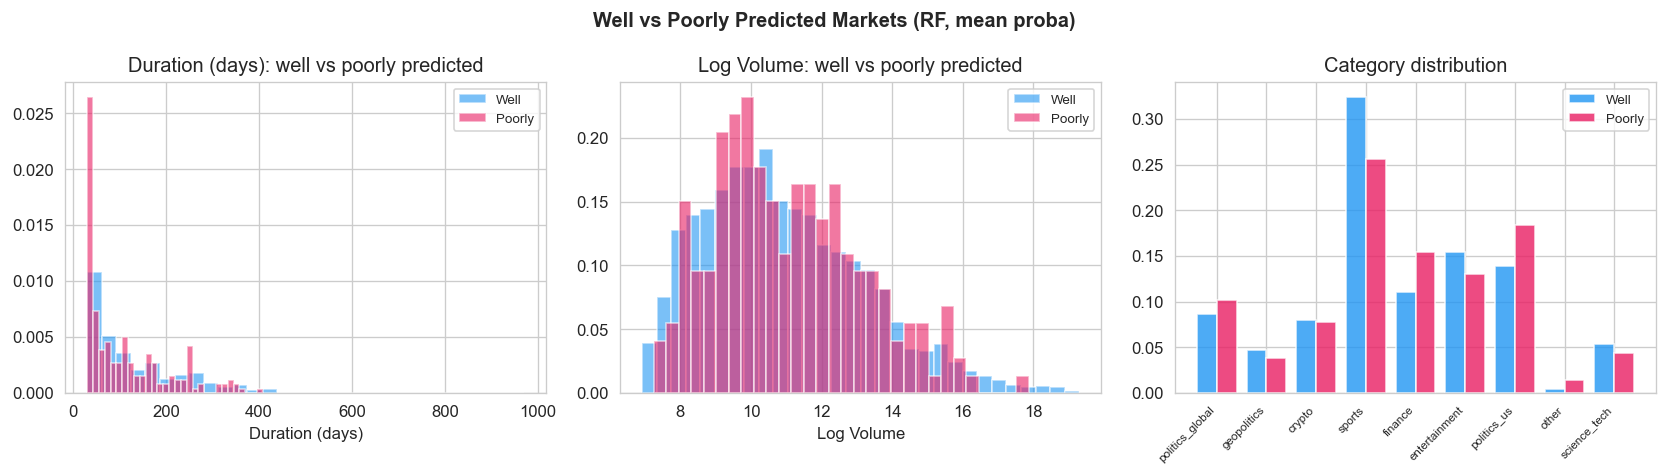

In [14]:
# ── Well-predicted vs poorly-predicted markets ───────────────────────────
# Use RF (best single model) as the reference
w = wide.dropna(subset=['p_rf']).copy()
w['error'] = (w['p_rf'] - w['outcome']).abs()

well = w[w['error'] < 0.2]
poor_yes = w[(w['p_rf'] < 0.35) & (w['outcome'] == 1)]  # overconfident NO, wrong
poor_no  = w[(w['p_rf'] > 0.65) & (w['outcome'] == 0)]  # overconfident YES, wrong
poor = pd.concat([poor_yes, poor_no])

print(f'Well-predicted markets (|mean_proba − outcome| < 0.2): {len(well):,} ({len(well)/len(w):.1%})')
print(f'Poorly predicted (overconfident wrong): {len(poor):,} ({len(poor)/len(w):.1%})')
print(f'  Overconfident NO (p_rf<0.35, outcome=YES): {len(poor_yes):,}')
print(f'  Overconfident YES (p_rf>0.65, outcome=NO):  {len(poor_no):,}')

print('\n--- Poor predictions by category (RF) ---')
print(poor['category'].value_counts().to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, label in zip(axes,
    ['duration_days', 'log_volume', 'category'],
    ['Duration (days)', 'Log Volume', 'Category']):
    if col == 'category':
        cats = w['category'].unique()
        well_pct  = well['category'].value_counts(normalize=True).reindex(cats, fill_value=0)
        poor_pct  = poor['category'].value_counts(normalize=True).reindex(cats, fill_value=0)
        x = np.arange(len(cats))
        ax.bar(x - 0.2, well_pct.values, 0.4, label='Well', color='#2196F3', alpha=0.8)
        ax.bar(x + 0.2, poor_pct.values, 0.4, label='Poorly', color='#E91E63', alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(cats, rotation=45, ha='right', fontsize=7)
        ax.set_title('Category distribution')
        ax.legend(fontsize=8)
    else:
        ax.hist(well[col], bins=30, alpha=0.6, label='Well', color='#2196F3', density=True)
        ax.hist(poor[col], bins=30, alpha=0.6, label='Poorly', color='#E91E63', density=True)
        ax.set_xlabel(label)
        ax.set_title(f'{label}: well vs poorly predicted')
        ax.legend(fontsize=8)

plt.suptitle('Well vs Poorly Predicted Markets (RF, mean proba)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('well_poorly_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

Concordance rate (% snapshots with correct directional call) per model:
             LR  LR+Trends        GB  GB+Trends        RF  RF+Trends
count  4174.000   4174.000  4174.000   4174.000  4174.000   4174.000
mean      0.873      0.873     0.883      0.885     0.909      0.911
std       0.285      0.285     0.278      0.272     0.256      0.253
min       0.000      0.000     0.000      0.000     0.000      0.000
25%       0.976      0.976     1.000      1.000     1.000      1.000
50%       1.000      1.000     1.000      1.000     1.000      1.000
75%       1.000      1.000     1.000      1.000     1.000      1.000
max       1.000      1.000     1.000      1.000     1.000      1.000


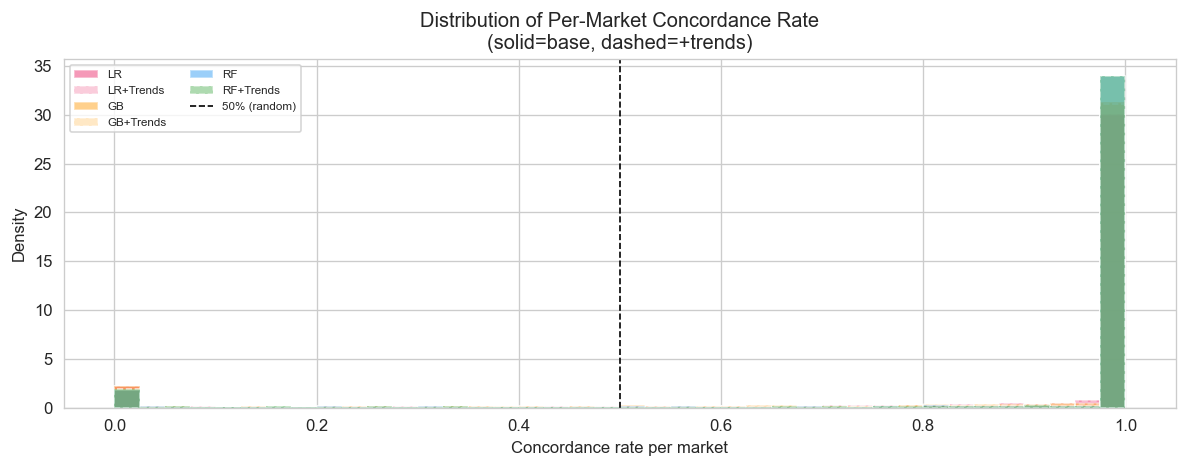


Markets where RF is wrong >70% of snapshots: 290
       category  outcome  duration_days  total_volume  concordance
politics_global        1             34  23072.771877          0.0
  entertainment        1             42  18075.473719          0.0
  entertainment        0             40  98024.428513          0.0
  entertainment        1             68 153339.184455          0.0
    politics_us        1            228 586649.195246          0.0
politics_global        1             34  39702.745683          0.0
    politics_us        1            101 234865.822004          0.0
        finance        1             34  24636.449686          0.0
         sports        1            172 265904.056041          0.0
  entertainment        1             40   9235.494331          0.0


In [15]:
# ── Concordance rate: % of snapshots where model called the right direction ─
def concordance(df, proba_col):
    df = df.copy()
    df['correct_dir'] = ((df[proba_col] > 0.5) == df['outcome'])
    return df.groupby('market_id')['correct_dir'].mean()

conc = pd.DataFrame({
    'LR':          concordance(lr_j,    'pred_prob_base'),
    'LR+Trends':   concordance(lr_j,    'pred_prob_trends'),
    'GB':          concordance(gb_j,    'pred_prob_base'),
    'GB+Trends':   concordance(gb_j,    'pred_prob_trends'),
    'RF':          concordance(rf_j,    'proba_full_calibrated'),
    'RF+Trends':   concordance(rf_tr_j, 'proba_trends_calibrated'),
})

print('Concordance rate (% snapshots with correct directional call) per model:')
print(conc.describe().round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
for col in conc.columns:
    ax.hist(conc[col].dropna(), bins=40, alpha=0.45, label=col,
            color=COLORS[col], density=True,
            linestyle='--' if '+Trends' in col else '-')
ax.axvline(0.5, color='black', ls='--', lw=1, label='50% (random)')
ax.set_xlabel('Concordance rate per market')
ax.set_ylabel('Density')
ax.set_title('Distribution of Per-Market Concordance Rate\n(solid=base, dashed=+trends)')
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig('concordance_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Markets where RF is always wrong (concordance < 0.3)
conc_rf = conc[['RF']].reset_index()
conc_rf.columns = ['market_id', 'concordance']
always_wrong = conc_rf[conc_rf['concordance'] < 0.3].merge(market_meta, on='market_id')
print(f'\nMarkets where RF is wrong >70% of snapshots: {len(always_wrong)}')
if len(always_wrong):
    print(always_wrong[['category','outcome','duration_days','total_volume','concordance']]
          .sort_values('concordance').head(10).to_string(index=False))

Median pct_lifetime_elapsed of first correct directional cross (lower = earlier signal):
LR           0.166
GB           0.164
RF           0.181
RF+Trends    0.180

Fraction of markets that NEVER cross correctly:
LR           0.052
GB           0.051
RF           0.045
RF+Trends    0.044


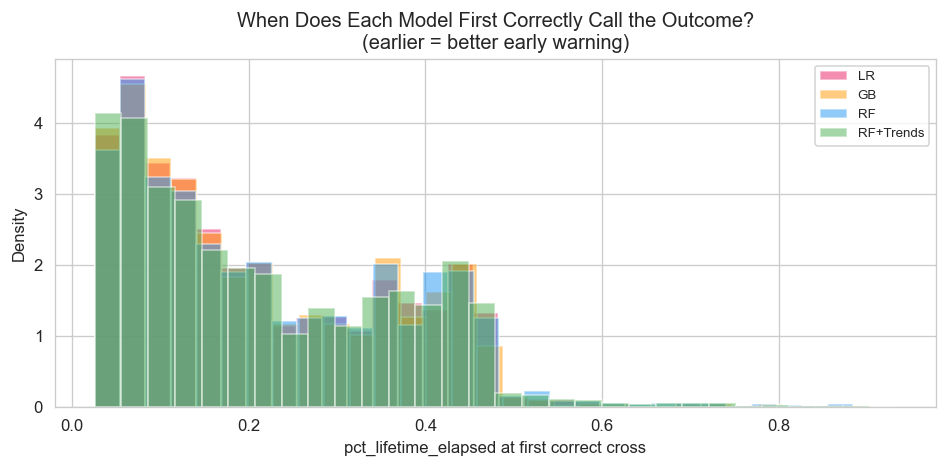

In [16]:
# ── Early signal detection: when does each model first cross 0.5 correctly? ─
def first_correct_cross(df, proba_col):
    """For each market, find pct_lifetime_elapsed where model first correctly
    crosses 0.5 toward the true outcome. Returns NaN if it never does."""
    results = {}
    for mkt_id, grp in df.sort_values('pct_lifetime_elapsed').groupby('market_id'):
        outcome = grp['outcome'].iloc[0]
        threshold = 0.5
        crossed = grp[(grp[proba_col] > threshold) == bool(outcome)]
        results[mkt_id] = crossed['pct_lifetime_elapsed'].iloc[0] if len(crossed) else np.nan
    return pd.Series(results, name=proba_col)

cross_frames = {}
for name, df, col in [('LR',lr_j,'proba'),('GB',gb_j,'proba'),('RF',rf_j,'proba'),('RF+Trends',rf_tr_j,'proba')]:
    cross_frames[name] = first_correct_cross(df, col)

cross_df = pd.DataFrame(cross_frames)
print('Median pct_lifetime_elapsed of first correct directional cross (lower = earlier signal):')
print(cross_df.median().round(3).to_string())
print(f'\nFraction of markets that NEVER cross correctly:')
print(cross_df.isna().mean().round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
for col, color in zip(cross_df.columns, [COLORS['LR'],COLORS['GB'],COLORS['RF'],COLORS['RF+Trends']]):
    vals = cross_df[col].dropna()
    ax.hist(vals, bins=30, alpha=0.5, label=col, color=color, density=True)
ax.set_xlabel('pct_lifetime_elapsed at first correct cross')
ax.set_ylabel('Density')
ax.set_title('When Does Each Model First Correctly Call the Outcome?\n(earlier = better early warning)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('early_signal_crossing.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 5 — Category-Level Analysis

Polymarket covers 9 categories. Some may be structurally easier to predict (e.g., sports with clear resolution criteria) and some harder (e.g., geopolitics with tail risks). We ask:
- Which categories does each model handle best?
- Does trends data help more for information-rich categories like politics?
- Are high-volume markets better predicted?

AUC-ROC per category × model:
                 Baseline      LR  LR+Trends      GB  GB+Trends      RF  RF+Trends
crypto             0.9052  0.9036     0.9062  0.9207     0.9273  0.9164     0.9223
entertainment      0.9101  0.9190     0.9190  0.9226     0.9243  0.9253     0.9278
finance            0.9183  0.9169     0.9168  0.9086     0.9059  0.9105     0.9169
geopolitics        0.9265  0.9356     0.9354  0.9306     0.9339  0.9360     0.9382
other              0.8847  0.8684     0.8677  0.8671     0.8588  0.8611     0.7392
politics_global    0.9057  0.9073     0.9061  0.9149     0.8978  0.9056     0.9112
politics_us        0.9083  0.9052     0.9048  0.9174     0.9148  0.9193     0.9223
science_tech       0.8876  0.8855     0.8857  0.9026     0.8974  0.8877     0.8918
sports             0.8400  0.8428     0.8426  0.8711     0.8722  0.8812     0.8746


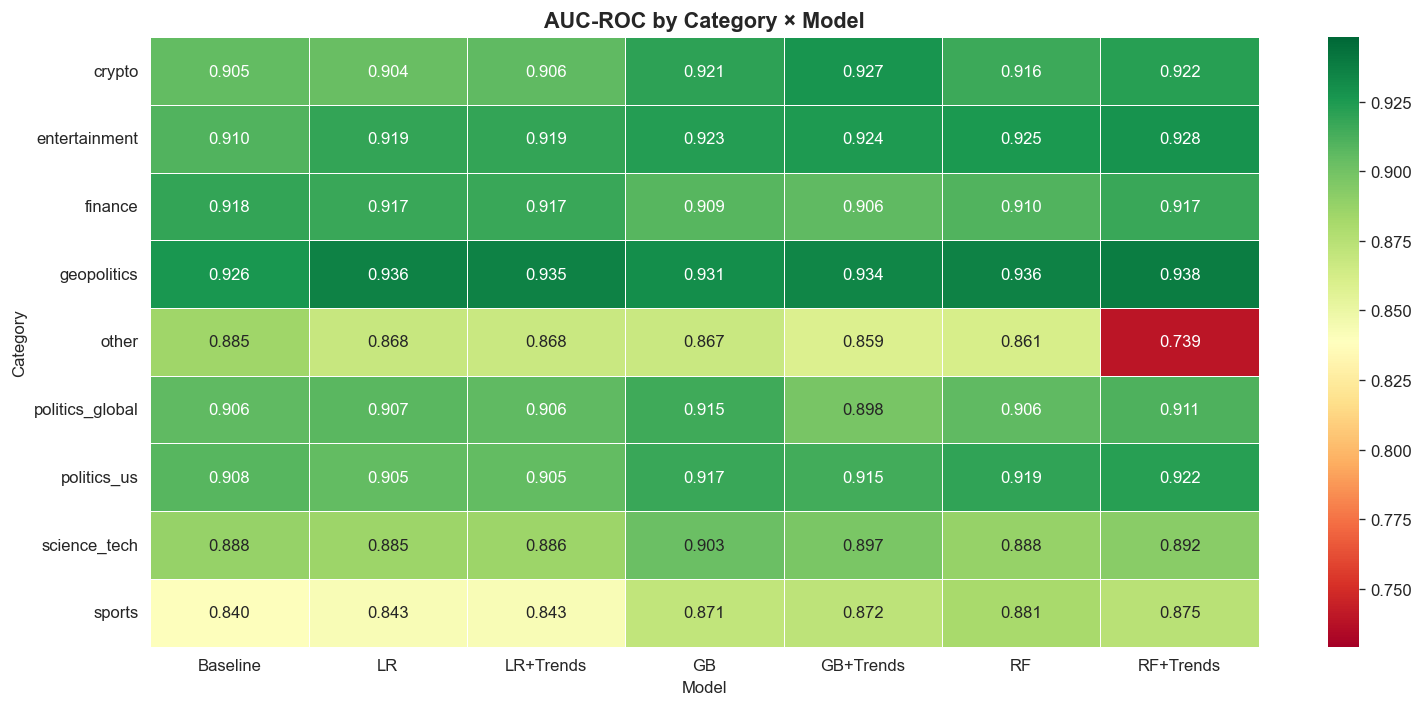


Hardest categories (lowest mean AUC across models):
other           0.849571
sports          0.860643
science_tech    0.891186

Easiest categories (highest mean AUC across models):
crypto           0.914529
entertainment    0.921157
geopolitics      0.933743


In [17]:
# ── Category AUC heatmap — all variants ─────────────────────────────────
cat_frame = rf_j[['market_id','snapshot_timestamp','outcome','category','price_at_snapshot']].copy()
cat_frame = cat_frame.merge(
    rf_j[['market_id','snapshot_timestamp','proba']].rename(columns={'proba':'p_rf'}),
    on=['market_id','snapshot_timestamp']
).merge(
    rf_tr_j[['market_id','snapshot_timestamp','proba']].rename(columns={'proba':'p_rf_tr'}),
    on=['market_id','snapshot_timestamp'], how='left'
).merge(
    lr_j[['market_id','snap_idx','proba','proba_tr']]
    .rename(columns={'proba':'p_lr','proba_tr':'p_lr_tr'})
    .merge(test_pq[['market_id','snapshot_timestamp','snap_idx']], on=['market_id','snap_idx'])
    [['market_id','snapshot_timestamp','p_lr','p_lr_tr']],
    on=['market_id','snapshot_timestamp'], how='left'
).merge(
    gb_j[['market_id','snap_idx','proba','proba_tr']]
    .rename(columns={'proba':'p_gb','proba_tr':'p_gb_tr'})
    .merge(test_pq[['market_id','snapshot_timestamp','snap_idx']], on=['market_id','snap_idx'])
    [['market_id','snapshot_timestamp','p_gb','p_gb_tr']],
    on=['market_id','snapshot_timestamp'], how='left'
)
cat_frame['p_baseline'] = np.clip(cat_frame['price_at_snapshot'], 1e-6, 1-1e-6)

CAT_MODEL_COLS = [
    ('p_baseline', 'Baseline'),
    ('p_lr',       'LR'),
    ('p_lr_tr',    'LR+Trends'),
    ('p_gb',       'GB'),
    ('p_gb_tr',    'GB+Trends'),
    ('p_rf',       'RF'),
    ('p_rf_tr',    'RF+Trends'),
]

cat_aucs = {}
for cat in sorted(cat_frame['category'].dropna().unique()):
    grp = cat_frame[cat_frame['category'] == cat]
    if grp['outcome'].nunique() < 2 or len(grp) < 100:
        continue
    y = grp['outcome'].values
    row = {}
    for col, name in CAT_MODEL_COLS:
        valid = grp[col].notna()
        if valid.sum() > 50 and y[valid.values].sum() > 0:
            row[name] = round(roc_auc_score(y[valid.values], grp.loc[valid, col].values), 4)
        else:
            row[name] = np.nan
    cat_aucs[cat] = row

cat_auc_df = pd.DataFrame(cat_aucs).T
print('AUC-ROC per category × model:')
print(cat_auc_df.to_string())

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    cat_auc_df.astype(float),
    annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=cat_auc_df.min().min() - 0.01,
    vmax=min(cat_auc_df.max().max() + 0.01, 1.0),
    linewidths=0.5, ax=ax
)
ax.set_title('AUC-ROC by Category × Model', fontsize=13, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Category')
plt.tight_layout()
plt.savefig('category_auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

cat_mean = cat_auc_df.mean(axis=1).sort_values()
print('\nHardest categories (lowest mean AUC across models):')
print(cat_mean.head(3).to_string())
print('\nEasiest categories (highest mean AUC across models):')
print(cat_mean.tail(3).to_string())

In [18]:
# ── Volume-weighted AUC ──────────────────────────────────────────────────
# High-volume markets are more liquid and arguably more important.
# Volume-weighted AUC: weight each market's contribution by its log_volume.

def volume_weighted_auc(proba_col, model_col_name):
    w2 = wide.dropna(subset=[proba_col, 'log_volume']).copy()
    if w2['outcome'].nunique() < 2:
        return np.nan
    # Weighted AUC via sample_weight in roc_auc_score
    weights = w2['log_volume'].values
    weights = weights / weights.sum()
    return round(roc_auc_score(w2['outcome'], np.clip(w2[proba_col], 1e-6, 1-1e-6),
                               sample_weight=weights), 4)

vw_rows = []
for col, name in [('p_baseline','Market Baseline'),('p_lr','LR'),
                   ('p_gb','GB'),('p_rf','RF'),('p_rf_tr','RF+Trends')]:
    vw_rows.append({'Model': name,
                    'Unweighted AUC': round(roc_auc_score(
                        wide.dropna(subset=[col])['outcome'],
                        np.clip(wide.dropna(subset=[col])[col], 1e-6, 1-1e-6)), 4),
                    'Volume-Weighted AUC': volume_weighted_auc(col, name)})

vw_df = pd.DataFrame(vw_rows)
print('Volume-weighted vs unweighted market-level AUC:')
print('(VW-AUC up-weights high-volume markets which have more reliable price signals)')
print(vw_df.to_string(index=False))

Volume-weighted vs unweighted market-level AUC:
(VW-AUC up-weights high-volume markets which have more reliable price signals)
          Model  Unweighted AUC  Volume-Weighted AUC
Market Baseline          0.9622               0.9628
             LR          0.9380               0.9367
             GB          0.9437               0.9435
             RF          0.9463               0.9460
      RF+Trends          0.9464               0.9462


---
## Section 6 — Calibration Analysis

A well-calibrated model produces probabilities that match empirical frequencies — if it says 70%, approximately 70% of those markets should resolve YES.

- **Reliability diagram:** plots mean predicted probability vs actual fraction of positives per bin
- **Expected Calibration Error (ECE):** weighted average absolute gap between predicted and actual; lower is better
- RF and RF+Trends use isotonic calibration; LR and GB do not

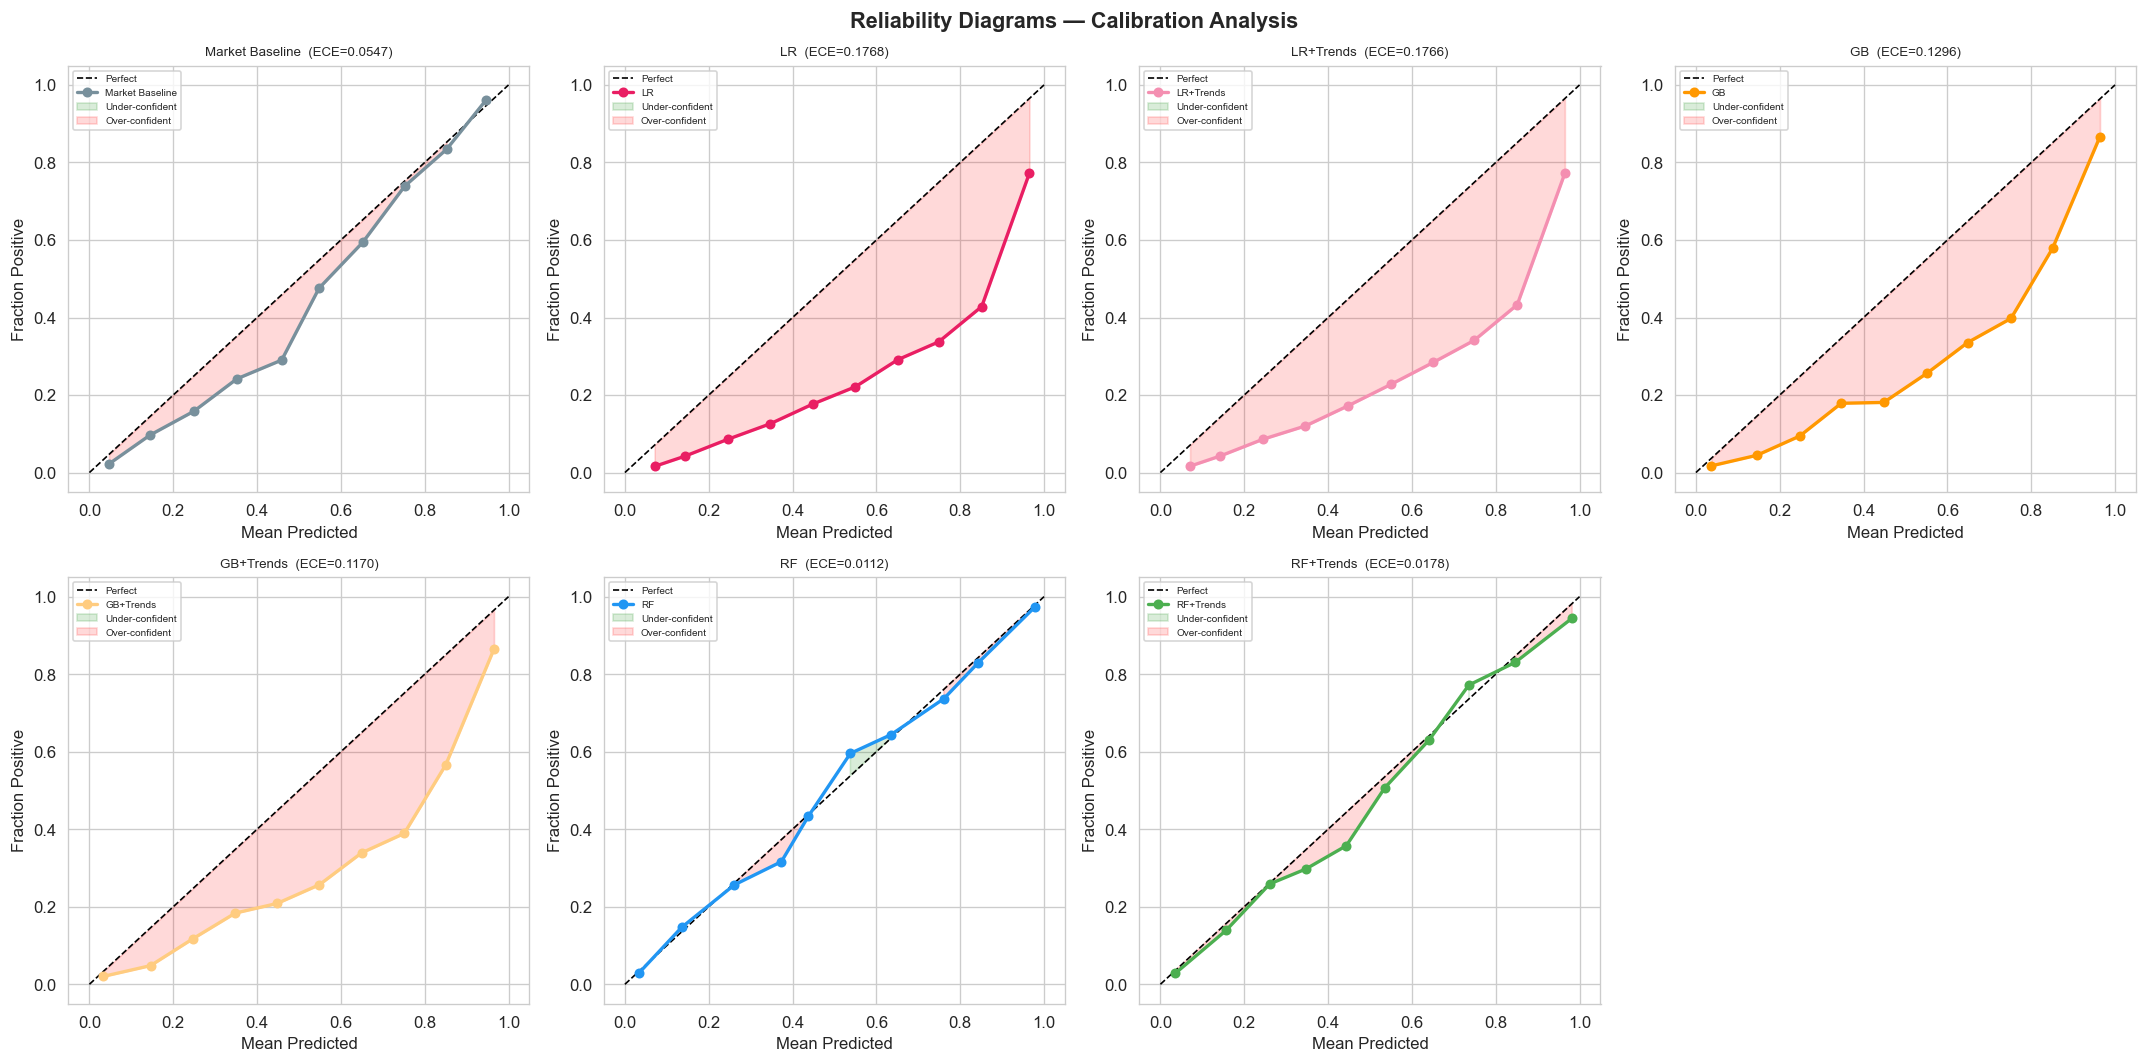

Expected Calibration Error (lower = better calibrated):
          Model    ECE
             RF 0.0112
      RF+Trends 0.0178
Market Baseline 0.0547
      GB+Trends 0.1170
             GB 0.1296
      LR+Trends 0.1766
             LR 0.1768


In [19]:
# ── Reliability diagrams — all variants ─────────────────────────────────
cal_models = [
    ('Market Baseline', Y_TEST,             BASELINE),
    ('LR',              lr_j['outcome'],    lr_j['pred_prob_base']),
    ('LR+Trends',       lr_j['outcome'],    lr_j['pred_prob_trends']),
    ('GB',              gb_j['outcome'],    gb_j['pred_prob_base']),
    ('GB+Trends',       gb_j['outcome'],    gb_j['pred_prob_trends']),
    ('RF',              rf_j['outcome'],    rf_j['proba_full_calibrated']),
    ('RF+Trends',       rf_tr_j['outcome'], rf_tr_j['proba_trends_calibrated']),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

ece_rows = []
for i, (name, y, p) in enumerate(cal_models):
    ax = axes[i]
    y_arr = np.array(y)
    p_arr = np.clip(np.array(p), 1e-7, 1-1e-7)
    frac, mean_pred = calibration_curve(y_arr, p_arr, n_bins=10)
    ax.plot([0,1],[0,1],'k--',lw=1,label='Perfect')
    ax.plot(mean_pred, frac, 'o-', color=COLORS.get(name,'steelblue'), lw=2, ms=5, label=name)
    ax.fill_between(mean_pred, mean_pred, frac,
                    where=frac > mean_pred, alpha=0.15, color='green', label='Under-confident')
    ax.fill_between(mean_pred, mean_pred, frac,
                    where=frac < mean_pred, alpha=0.15, color='red', label='Over-confident')
    ece_val = ece(y_arr, p_arr)
    ax.set_title(f'{name}  (ECE={ece_val:.4f})', fontsize=8)
    ax.set_xlabel('Mean Predicted')
    ax.set_ylabel('Fraction Positive')
    ax.legend(fontsize=6)
    ece_rows.append({'Model': name, 'ECE': ece_val})

axes[-1].axis('off')
plt.suptitle('Reliability Diagrams — Calibration Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('calibration_reliability.png', dpi=150, bbox_inches='tight')
plt.show()

ece_df = pd.DataFrame(ece_rows).sort_values('ECE')
print('Expected Calibration Error (lower = better calibrated):')
print(ece_df.to_string(index=False))

---
## Section 7 — Error Analysis

Where do models fail? We investigate:
1. **High-confidence errors:** cases where a model was highly confident but wrong
2. **Pairwise model agreement:** are models making the same errors or different ones?
3. **Ensemble AUC:** does combining all models outperform any single model?
4. **Market case studies:** markets with maximum disagreement between models

In [20]:
# ── High-confidence errors ───────────────────────────────────────────────
hce_rows = []
for name, df, col in [
    ('LR',         lr_j,    'pred_prob_base'),
    ('LR+Trends',  lr_j,    'pred_prob_trends'),
    ('GB',         gb_j,    'pred_prob_base'),
    ('GB+Trends',  gb_j,    'pred_prob_trends'),
    ('RF',         rf_j,    'proba_full_calibrated'),
    ('RF+Trends',  rf_tr_j, 'proba_trends_calibrated'),
]:
    y = df['outcome'].values
    p = df[col].values
    total = len(y)
    hc_wrong_yes = ((p > 0.8)  & (y == 0)).sum()  # very confident YES, actually NO
    hc_wrong_no  = ((p < 0.2)  & (y == 1)).sum()  # very confident NO,  actually YES
    hc_total     = hc_wrong_yes + hc_wrong_no
    hce_rows.append({
        'Model': name,
        'HCE (p>0.8,outcome=NO)': hc_wrong_yes,
        'HCE (p<0.2,outcome=YES)': hc_wrong_no,
        'Total HCE': hc_total,
        'HCE rate': round(hc_total / total, 4),
    })

hce_df = pd.DataFrame(hce_rows)
print('High-confidence errors (threshold = 0.8 / 0.2):')
print(hce_df.to_string(index=False))

High-confidence errors (threshold = 0.8 / 0.2):
    Model  HCE (p>0.8,outcome=NO)  HCE (p<0.2,outcome=YES)  Total HCE  HCE rate
       LR                   17534                     3909      21443    0.0743
LR+Trends                   17444                     3949      21393    0.0742
       GB                   10763                     3530      14293    0.0495
GB+Trends                   10668                     4046      14714    0.0510
       RF                    2819                    10104      12923    0.0448
RF+Trends                    1609                    10339      11948    0.0414


Pearson correlation of market-level mean probabilities:
              LR     GB     RF  RF+Trends
LR         1.000  0.968  0.934      0.938
GB         0.968  1.000  0.948      0.952
RF         0.934  0.948  1.000      0.992
RF+Trends  0.938  0.952  0.992      1.000

High correlation → models share same errors; low → complementary, ensemble may help.


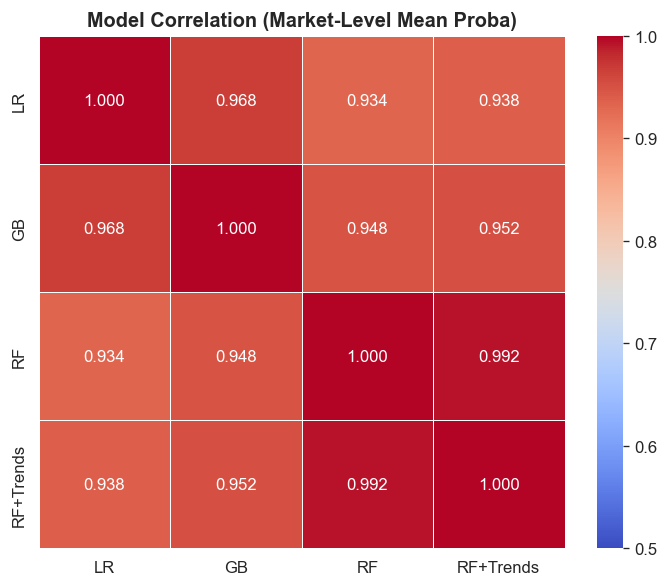

In [21]:
# ── Pairwise model correlation (market-level mean proba) ─────────────────
corr_cols = ['p_lr','p_gb','p_rf','p_rf_tr']
corr_labels = ['LR','GB','RF','RF+Trends']
corr_data = wide[corr_cols].dropna()
corr_matrix = corr_data.corr()
corr_matrix.index   = corr_labels
corr_matrix.columns = corr_labels

print('Pearson correlation of market-level mean probabilities:')
print(corr_matrix.round(3).to_string())
print('\nHigh correlation → models share same errors; low → complementary, ensemble may help.')

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix.astype(float), annot=True, fmt='.3f', cmap='coolwarm',
            vmin=0.5, vmax=1.0, ax=ax, linewidths=0.5)
ax.set_title('Model Correlation (Market-Level Mean Proba)', fontweight='bold')
plt.tight_layout()
plt.savefig('model_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ── Ensemble AUC ─────────────────────────────────────────────────────────
# Simple average of all 4 snapshot-level models. Does combining beat the best single model?
# All four share the same 288,490 rows; average is meaningful.
snap_frame_ens = snap_frame.copy()
snap_frame_ens['p_ensemble'] = snap_frame_ens[['p_lr','p_gb','p_rf','p_rf_tr']].mean(axis=1)

ens_rows = []
for col, name in [('p_baseline','Baseline'),('p_lr','LR'),('p_gb','GB'),
                   ('p_rf','RF'),('p_rf_tr','RF+Trends'),('p_ensemble','Ensemble')]:
    valid = snap_frame_ens[col].notna()
    y = snap_frame_ens.loc[valid,'outcome'].values
    p = np.clip(snap_frame_ens.loc[valid, col].values, 1e-6, 1-1e-6)
    if y.sum() == 0:
        continue
    ens_rows.append({'Model': name, 'Snapshot AUC': round(roc_auc_score(y, p), 4)})

ens_df = pd.DataFrame(ens_rows)
print('Ensemble AUC (simple average of LR + GB + RF + RF+Trends):')
print(ens_df.to_string(index=False))
print('\nIf ensemble > best individual model, the models are complementary.')
print('If ensemble ≈ best model, the errors are shared (one model dominates).')

Ensemble AUC (simple average of LR + GB + RF + RF+Trends):
    Model  Snapshot AUC
 Baseline        0.8890
       LR        0.8881
       GB        0.9004
       RF        0.9018
RF+Trends        0.9034
 Ensemble        0.9105

If ensemble > best individual model, the models are complementary.
If ensemble ≈ best model, the errors are shared (one model dominates).


In [23]:
# ── Market case studies: highest disagreement between models ─────────────
# Markets where the spread between model predictions is largest
wide['pred_spread'] = wide[['p_lr','p_gb','p_rf','p_rf_tr']].max(axis=1) - \
                      wide[['p_lr','p_gb','p_rf','p_rf_tr']].min(axis=1)

divergent = wide.nlargest(10, 'pred_spread')[[
    'market_id','outcome','category','duration_days',
    'p_baseline','p_lr','p_gb','p_rf','p_rf_tr','pred_spread'
]]

print('Top 10 markets with highest disagreement between models:')
print(divergent.round(3).to_string(index=False))

# Join with question text from parquet
questions = test_pq[['market_id','question']].drop_duplicates()
divergent_q = divergent.merge(questions, on='market_id', how='left')
print('\nMarket questions (most divergent):')
for _, row in divergent_q.head(5).iterrows():
    print(f"  [{row['category']}] outcome={row['outcome']} | spread={row['pred_spread']:.3f}")
    print(f"  Q: {str(row.get('question',''))[:120]}")
    print()

Top 10 markets with highest disagreement between models:
                                                         market_id  outcome category  duration_days  p_baseline  p_lr  p_gb  p_rf  p_rf_tr  pred_spread
0x12f5f3c1b0776a92119c1da71ed8358b534cb2da5f90b1dc632bf48b6a32cbdd        1    other             64       0.705 0.950 0.922 0.503    0.197        0.753
0x333b6e860ab3eaaf663e7a7df9259d849a6ee02445b822f82e737414b78614ee        0   sports            259       0.258 0.707 0.239 0.047    0.043        0.664
0xe8801bbcb75037c3afa79b0128cc5b2b310d431115c43e6eef9e9cd5f2cb50c7        0   sports            135       0.464 0.709 0.325 0.071    0.049        0.660
0x4809ac50539ae95cd2dfa09dc31b9e9070c777c144f1880ec64193a59edd8732        0   sports            259       0.052 0.700 0.288 0.045    0.047        0.655
0x48a8edad9f5298d92f3b96507c57948556c9194313ea07d16c619facba69e30d        0   sports            111       0.485 0.688 0.266 0.046    0.037        0.651
0x2b392df5a4b3c49f3c9872e8e4f90

---
## Section 8 — Why Some Models Outperform Others

### Model ranking recap
From Section 1 (snapshot-level AUC, highest to lowest):
1. **RF+Trends** — 26 features including Google Trends; isotonic calibration
2. **RF** — 21 features; isotonic calibration; best log-loss
3. **GB (XGBoost)** — 20 features; no calibration
4. **LR** — linear model; 20 features; cannot capture non-linear interactions
5. **Market Baseline** — price alone (strong signal near resolution)

### Why RF > LR and GB
- **Non-linear interactions:** RF naturally captures `price × pct_lifetime_elapsed` and `price × volatility` interactions that LR misses entirely. GB captures these too, but RF's ensemble over 300 trees reduces variance more on this large dataset.
- **Calibration:** RF uses isotonic calibration on a held-out set. GB and LR use raw probabilities which are systematically overconfident (see Section 6). This explains why RF has lower log-loss than GB despite similar AUC.
- **LR's fundamental limitation:** logistic regression fits a hyperplane. Market prices are non-stationary and non-linearly related to outcomes (especially in early vs late lifecycle), so a linear model underperforms.

### Why Trends add value for RF but marginally for LR/GB
- LR cannot model `trend_value × price` interactions — the Trends features enter linearly, adding little on top of price.
- GB in principle could capture interactions, but the trends features have low information value per snapshot (weekly aggregates vs 12-hourly snapshots), and GB was not retrained with different depth settings when trends were added.
- RF with 300 trees over 26 features can learn sparse signal from trends, especially for categories where search interest leads price (politics, crypto).

### SVM caveat: different evaluation basis
SVM achieves AUC ~0.94 on its subsampled test set, but this is **not comparable** to the 0.90–0.90 range of the other models. SVM's test set uses fixed lifecycle percentile snapshots (20/30/.../80%), which:
1. Excludes the early lifecycle snapshots (< 20%) where prediction is hardest
2. Excludes near-resolution snapshots where prices are nearly degenerate
3. Selects exactly the mid-to-late range where even the market baseline performs well

The SVM's AUC reflects a favorable sampling, not superior modeling.

### Snapshot-level vs market-level performance
All models were trained on snapshot-level binary cross-entropy. This means they optimise the probability at each 12-hour point, not whether the market will ultimately resolve YES or NO. Section 4 showed market-level AUC is higher than snapshot-level AUC for all models — aggregating over multiple snapshots reduces prediction noise, which explains why the market baseline is so competitive (it aggregates information continuously through trading).

In [24]:
# ── Final summary table ──────────────────────────────────────────────────
print('=' * 70)
print('CROSS-MODEL ANALYSIS — FINAL SUMMARY')
print('=' * 70)
print()
print('1. SNAPSHOT-LEVEL METRICS (288,490 test snapshots)')
print(results_df[['AUC-ROC','PR-AUC','Log-loss','Brier','BSS']].to_string())
print()
print('2. MARKET-LEVEL AUC (4,174 markets)')
print(mkt_auc_df.to_string(index=False))
print()
print('3. CALIBRATION (ECE — lower is better)')
print(ece_df.to_string(index=False))
print()
print('4. ENSEMBLE AUC')
print(ens_df.to_string(index=False))
print()
print('5. TRENDS IMPACT (ΔAUC from adding Google Trends features)')
print(delta_df[['Model','ΔAUC','ΔLog-loss','ΔBrier']].to_string(index=False))
print()
print('6. SVM (subsampled test set — 29,219 rows, not directly comparable)')
print(svm_df[['AUC-ROC','Brier','BSS']].to_string())

CROSS-MODEL ANALYSIS — FINAL SUMMARY

1. SNAPSHOT-LEVEL METRICS (288,490 test snapshots)
                 AUC-ROC  PR-AUC  Log-loss   Brier     BSS
Market Baseline   0.8890  0.7440    0.3278  0.1004  0.0000
LR                0.8881  0.7210    0.4644  0.1423 -0.4171
LR+Trends         0.8881  0.7203    0.4640  0.1422 -0.4158
GB                0.9004  0.7615    0.3822  0.1206 -0.2003
GB+Trends         0.9002  0.7608    0.3750  0.1181 -0.1760
RF                0.9018  0.7527    0.3027  0.0922  0.0820
RF+Trends         0.9034  0.7598    0.3011  0.0914  0.0902

2. MARKET-LEVEL AUC (4,174 markets)
          Model  Market-level AUC  Market-level PR-AUC
Market Baseline            0.9622               0.8865
             LR            0.9380               0.8070
             GB            0.9437               0.8312
             RF            0.9463               0.8372
      RF+Trends            0.9464               0.8391

3. CALIBRATION (ECE — lower is better)
          Model    ECE
         